Notebook exploring the Greens function of the vector derivative give in Doran and Lasenby 2003, pg 198.

In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=7

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import jax.random as random


import ginjax.geometric as geom
import ginjax.utils as utils

%load_ext autoreload
%autoreload 2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=7


In [ ]:

def Sd(D: int) -> jax.Array:
    """
    Calculate the surface area of a ball in D dimensions.

    args:
        D: dimension of the space

    returns:
        surface area of ball in D dimensions
    """
    return ((2 * jnp.pi) ** (D / 2)) / jax.scipy.special.gamma(D / 2)


def gradient(D: int, x0: jax.Array, is_torus: bool) -> jax.Array:
    """
    Given the initial temperature, time, and diffusion coefficient, calculate the new heat field.

    args:
        D: the dimension
        x0: the starting temperature array, shape (batch, spatial)
        is_torus: whether the data lives on the torus

    returns:
        the heat field after time t
    """
    eps = 1e-5
    batch = len(x0)
    spatial_dims = x0.shape[1:]
    x0_flat = x0.reshape((batch, -1))
    meshgrid_dims = (jnp.arange(N) for N in spatial_dims)

    vol = 1 / Sd(D)

    # (spatial_size,D)
    idxs = jnp.stack(jnp.meshgrid(*meshgrid_dims, indexing="ij"), axis=-1).reshape((-1, D))
    full_gradient = []
    for i, (idx, x0_val) in enumerate(zip(idxs, x0_flat.T)):
        # (spatial_size,D)
        if is_torus:
            idxs_diff = idxs - idx[None]
            idxs_diff_wrapped = jnp.stack(spatial_dims).reshape((1, D)) - jnp.abs(idxs_diff)

            dist = jnp.where(jnp.abs(idxs_diff) < idxs_diff_wrapped, idxs_diff, idxs_diff_wrapped)
        else:
            dist = idxs - idx[None]

        # (1,spatial_size)
        gradient_x = (vol * dist / (jnp.linalg.norm(dist, axis=-1, keepdims=True) ** D + eps))[None]
        full_gradient.append(jnp.sum(gradient_x * x0_flat[...,None], axis=1))  # (1,)
        #TODO: gradient only depends on closest pixels, not influence of far away pixels (like laplacian)

    return jnp.stack(full_gradient, axis=1).reshape(x0.shape + (D,))


D = 2
N = 16
batch = 1

key = random.PRNGKey(0)

key, subkey = random.split(key)
scalar_field = random.normal(subkey, shape=(batch,) + (N,) * D)
scalar_img = geom.GeometricImage(scalar_field[0], 0, D, True).convolve_with(
    geom.GeometricFilter(jnp.ones((3,3)), 0, D, True)
)
scalar_field = scalar_img.data[None]

gradient_field = gradient(D, scalar_field, True)


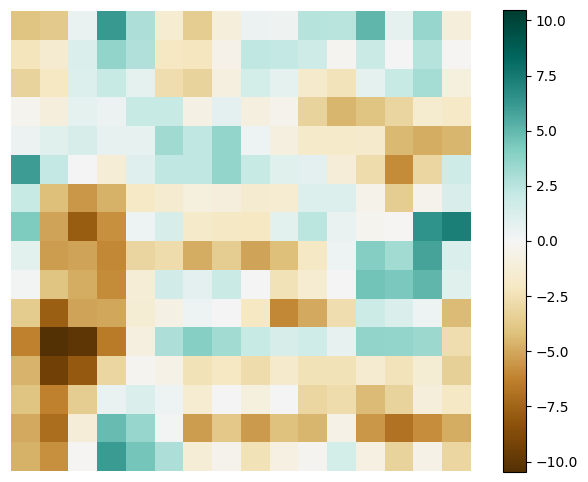

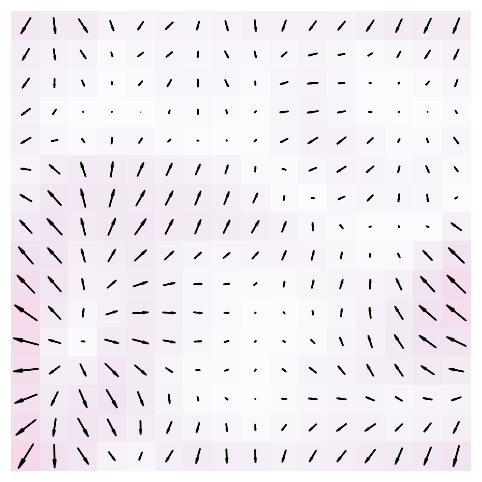

In [64]:
vmax = float(jnp.max(jnp.abs(scalar_field[0])))
geom.GeometricImage(scalar_field[0], 0, D, True).plot(vmin=-vmax, vmax=vmax, colorbar=True)
geom.GeometricImage(gradient_field[0] / 10, 0, D, True).plot(colorbar=True)